Importing All The Dependencies 

In [110]:
import os
import xml.etree.ElementTree as ET
from collections import Counter 
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from tqdm import tqdm
import cv2
import random

Dataset Folder 

In [111]:
Train_Img_Path = r"C:\Users\kiran\Downloads\archive\dataset-splitM\Training\images"
Train_Mask_Path = r"C:\Users\kiran\Downloads\archive\dataset-splitM\Training\GT"

Test_Img_Path = r"C:\Users\kiran\Downloads\archive\dataset-splitM\Testing\images"
Test_Mask_Path = r"C:\Users\kiran\Downloads\archive\dataset-splitM\Testing\GT"

In [112]:
def get_stems(folder):
    return set(Path(f).stem for f in os.listdir(folder))

train_img = get_stems(Train_Img_Path)
train_mask = get_stems(Train_Mask_Path) 

test_img = get_stems(Test_Img_Path)
test_mask = get_stems(Test_Mask_Path)   

print("TRAIN")
print("Images :", len(train_img))
print("Masks :", len(train_mask))
print("Missing Masks", len(train_img - train_mask))
print("Missing Images", len(train_mask - train_img))

print("TEST")
print("Images :", len(test_img))
print("Masks :", len(test_mask))
print("Missing Masks", len(test_img - test_mask))
print("Missing Images", len(test_mask - test_img))

TRAIN
Images : 748
Masks : 748
Missing Masks 0
Missing Images 0
TEST
Images : 330
Masks : 330
Missing Masks 0
Missing Images 0


In [113]:
img_stats = []
for folder in [Train_Img_Path, Test_Img_Path]:
    for img_file in tqdm(os.listdir(folder)):
        img_path = os.path.join(folder, img_file)
        img = cv2.imread(img_path)
        img_stats.append({
            "folder": os.path.basename(folder),
            "width": img.shape[1],
            "height": img.shape[0],
            "aspect_ratio": img.shape[1] / img.shape[0]
        })  

resolution_df = pd.DataFrame(img_stats)
resolution_df.head()

100%|██████████| 330/330 [00:02<00:00, 135.23it/s]


,folder,width,height,aspect_ratio
0,images,303,500,0.606000
1,images,720,430,1.674419
2,images,1280,720,1.777778
3,images,800,558,1.433692
4,images,375,500,0.750000


In [114]:
resolution_df.describe()

,width,height,aspect_ratio
count,1078.000000,1078.000000,1078.000000
mean,1054.990724,840.514842,1.308848
std,459.907071,402.814047,0.391117
min,209.000000,180.000000,0.510783
25%,750.000000,649.500000,1.000000
50%,1000.500000,720.000000,1.333333
75%,1280.000000,960.000000,1.777778
max,4775.000000,5472.000000,2.250879


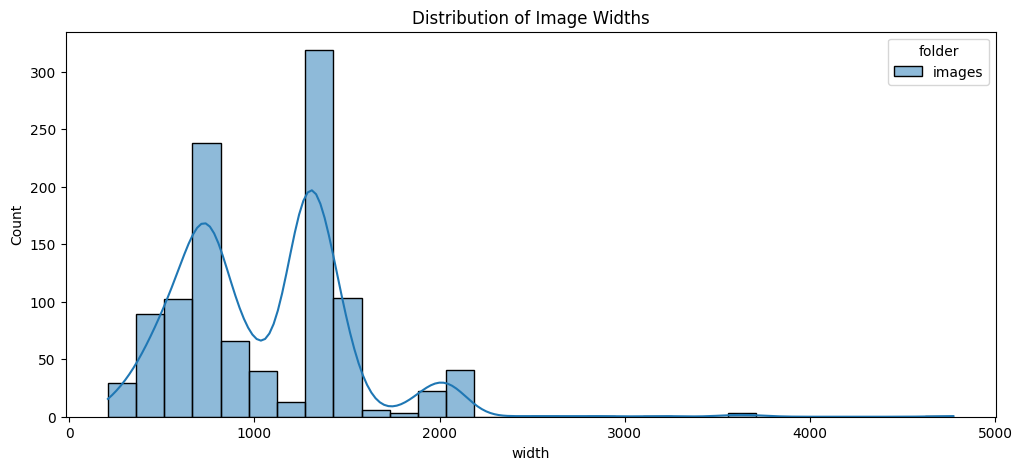

In [115]:
plt.figure(figsize=(12, 5))
sns.histplot(data=resolution_df, x="width", hue="folder", bins=30, kde=True)
plt.title("Distribution of Image Widths")   
plt.show()

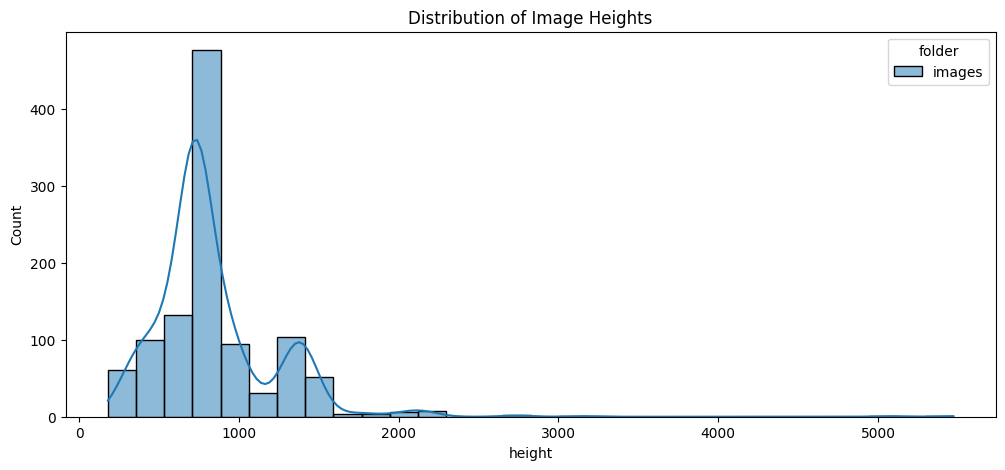

In [116]:
plt.figure(figsize=(12, 5))
sns.histplot(data=resolution_df, x="height", hue="folder", bins=30, kde=True)
plt.title("Distribution of Image Heights")
plt.show()  

Mask Coverage Analysis

In [117]:
coverage_data = []

for folder in [Train_Mask_Path, Test_Mask_Path]:

    for file in tqdm(os.listdir(folder)):

        path = os.path.join(folder, file)

        mask = cv2.imread(
            path,
            cv2.IMREAD_GRAYSCALE
        )

        _, binary = cv2.threshold(
            mask,
            127,
            255,
            cv2.THRESH_BINARY
        )

        total_pixels = binary.size

        foreground_pixels = np.sum(binary == 255)

        coverage = foreground_pixels / total_pixels

        coverage_data.append(coverage)

coverage_df = pd.DataFrame({
    "coverage": coverage_data
})

coverage_df.head()

100%|██████████| 330/330 [00:01<00:00, 267.02it/s]


,coverage
0,0.234442
1,0.286983
2,0.174302
3,0.042773
4,0.040747


In [118]:
coverage_df.describe()

,coverage
count,1078.000000
mean,0.185046
std,0.138923
min,0.001148
25%,0.068867
50%,0.162026
75%,0.258260
max,0.767829


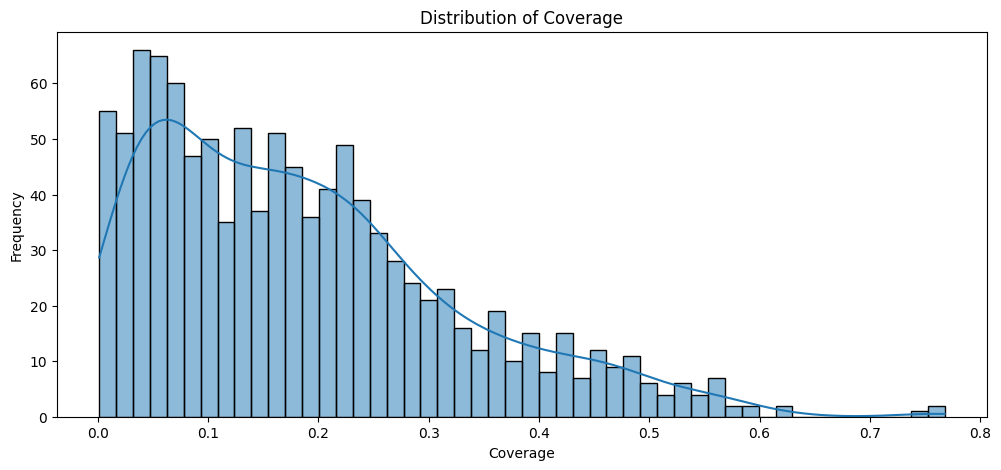

In [119]:
plt.figure(figsize=(12, 5))
sns.histplot(data=coverage_df, x='coverage', bins=50, kde=True)
plt.title("Distribution of Coverage")
plt.xlabel("Coverage")
plt.ylabel("Frequency")
plt.show()

In [120]:
component_stats = []

for folder in [Train_Mask_Path, Test_Mask_Path]:

    for file in tqdm(os.listdir(folder)):

        path = os.path.join(folder, file)

        mask = cv2.imread(
            path,
            cv2.IMREAD_GRAYSCALE
        )

        _, binary = cv2.threshold(
            mask,
            127,
            255,
            cv2.THRESH_BINARY
        )

        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary)

        valid_objects = 0

        for i in range(1, num_labels):

            x, y, w, h, area = stats[i]

            if area < 500:
                continue

            valid_objects += 1

        component_stats.append(valid_objects)

components_df = pd.DataFrame({
    "objects_per_image": component_stats
})

components_df.head()

100%|██████████| 330/330 [00:01<00:00, 213.68it/s]


,objects_per_image
0,1
1,2
2,1
3,3
4,1


In [121]:
components_df.describe()

,objects_per_image
count,1078.000000
mean,1.374768
std,1.261748
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,20.000000


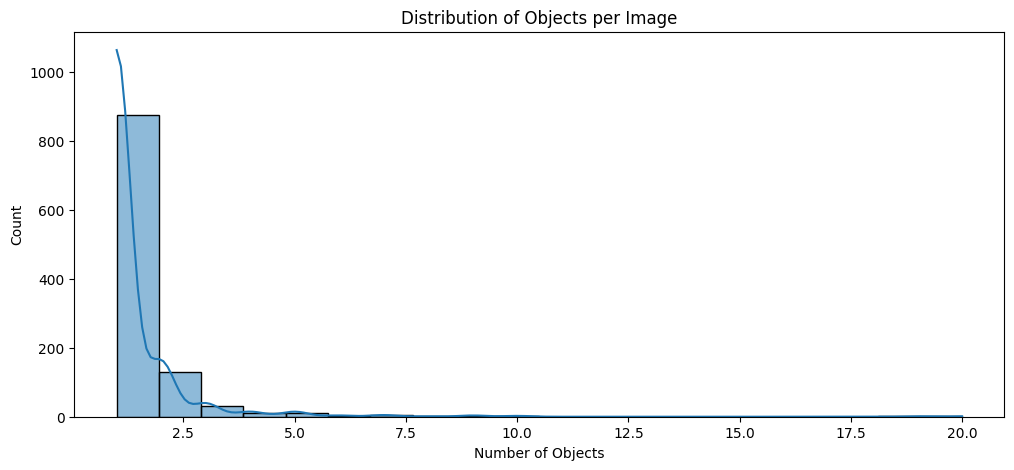

In [122]:
plt.figure(figsize=(12,5))
sns.histplot(components_df['objects_per_image'], bins=20, kde=True)
plt.title("Distribution of Objects per Image")
plt.xlabel("Number of Objects")
plt.show()

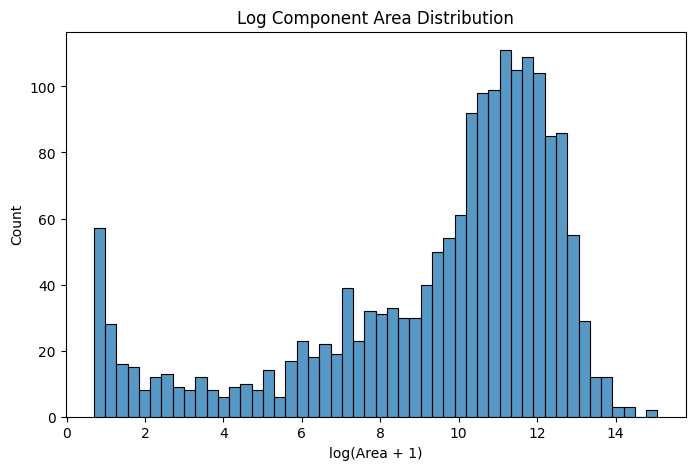

In [123]:
areas = []

for folder in [Train_Mask_Path, Test_Mask_Path]:

    for file in os.listdir(folder):

        path = os.path.join(folder, file)

        mask = cv2.imread(
            path,
            cv2.IMREAD_GRAYSCALE
        )

        _, binary = cv2.threshold(
            mask,
            127,
            255,
            cv2.THRESH_BINARY
        )

        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary)

        for i in range(1, num_labels):

            x, y, w, h, area = stats[i]

            areas.append(area)

plt.figure(figsize=(8,5))

sns.histplot(
    np.log1p(areas),
    bins=50
)

plt.title("Log Component Area Distribution")

plt.xlabel("log(Area + 1)")

plt.show()

In [124]:
bbox_stats=[]
for folder in [Train_Mask_Path, Test_Mask_Path]:
    for file in tqdm(os.listdir(folder)):
        mask_path = os.path.join(folder, file)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        h, w = mask.shape
        _,binary = cv2.threshold(mask,127,255,cv2.THRESH_BINARY)
        num_labels, labels,stats, _ = cv2.connectedComponentsWithStats(binary)
        for i in range(1,num_labels):
            x,y,bw,bh,area = stats[i]

            if area < 500 :
                continue
            bbox_stats.append({
                "folder": os.path.basename(folder),
                "width": bw,
                "height": bh,
                "area": area,
                "relative_area": area / (h * w)
            })
bbox_df = pd.DataFrame(bbox_stats)
bbox_df.head()

100%|██████████| 330/330 [00:01<00:00, 218.95it/s]


,folder,width,height,area,relative_area
0,GT,229,443,35518,0.234442
1,GT,243,381,60285,0.194719
2,GT,249,324,28565,0.092264
3,GT,772,408,160637,0.174302
4,GT,91,144,7227,0.016190


In [125]:
bbox_df.describe()

,width,height,area,relative_area
count,1482.000000,1482.000000,1.482000e+03,1482.000000
mean,386.786775,432.599865,1.247671e+05,0.134573
std,328.144449,315.320933,2.109330e+05,0.138891
min,12.000000,21.000000,5.090000e+02,0.000090
25%,150.250000,193.250000,1.582375e+04,0.019813
50%,305.500000,375.000000,5.847750e+04,0.088354
75%,544.000000,615.250000,1.551705e+05,0.212739
max,3510.000000,2893.000000,3.504953e+06,0.767829


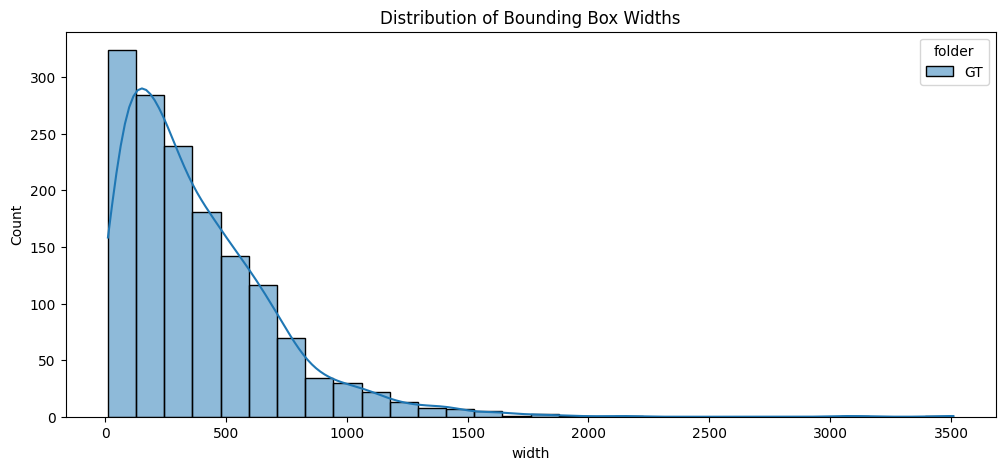

In [126]:
plt.figure(figsize=(12, 5))
sns.histplot(data=bbox_df, x='width', hue='folder', bins=30, kde=True)
plt.title("Distribution of Bounding Box Widths")
plt.show()

In [127]:
small = np.sum(bbox_df['relative_area'] < 0.01)
medium = np.sum((bbox_df['relative_area'] >= 0.01) & (bbox_df['relative_area'] < 0.1))
large = np.sum(bbox_df['relative_area'] >= 0.1) 

total = len(bbox_df)

print(f"Small : {100*small/total:.2f}%")
print(f"Medium : {100*medium/total:.2f}%")
print(f"Large : {100*large/total:.2f}%")

Small : 18.35%
Medium : 34.82%
Large : 46.83%


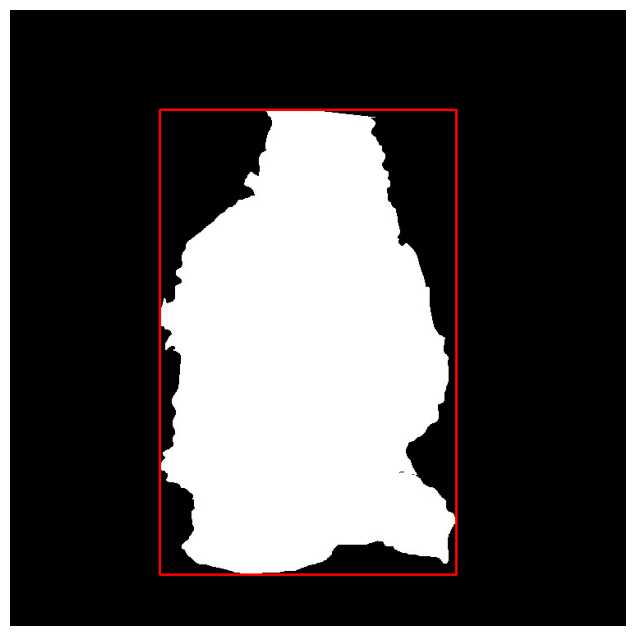

In [128]:
sample_file = random.choice(
    os.listdir(Train_Mask_Path)
)

mask_path = os.path.join(
    Train_Mask_Path,
    sample_file
)

mask = cv2.imread(
    mask_path,
    cv2.IMREAD_GRAYSCALE
)

rgb = cv2.cvtColor(
    mask,
    cv2.COLOR_GRAY2RGB
)

_, binary = cv2.threshold(
    mask,
    127,
    255,
    cv2.THRESH_BINARY
)

num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary)

for i in range(1, num_labels):

    x, y, w, h, area = stats[i]

    if area < 500:
        continue

    cv2.rectangle(
        rgb,
        (x,y),
        (x+w,y+h),
        (255,0,0),
        2
    )

plt.figure(figsize=(8,8))
plt.imshow(rgb)
plt.axis("off")
plt.show()

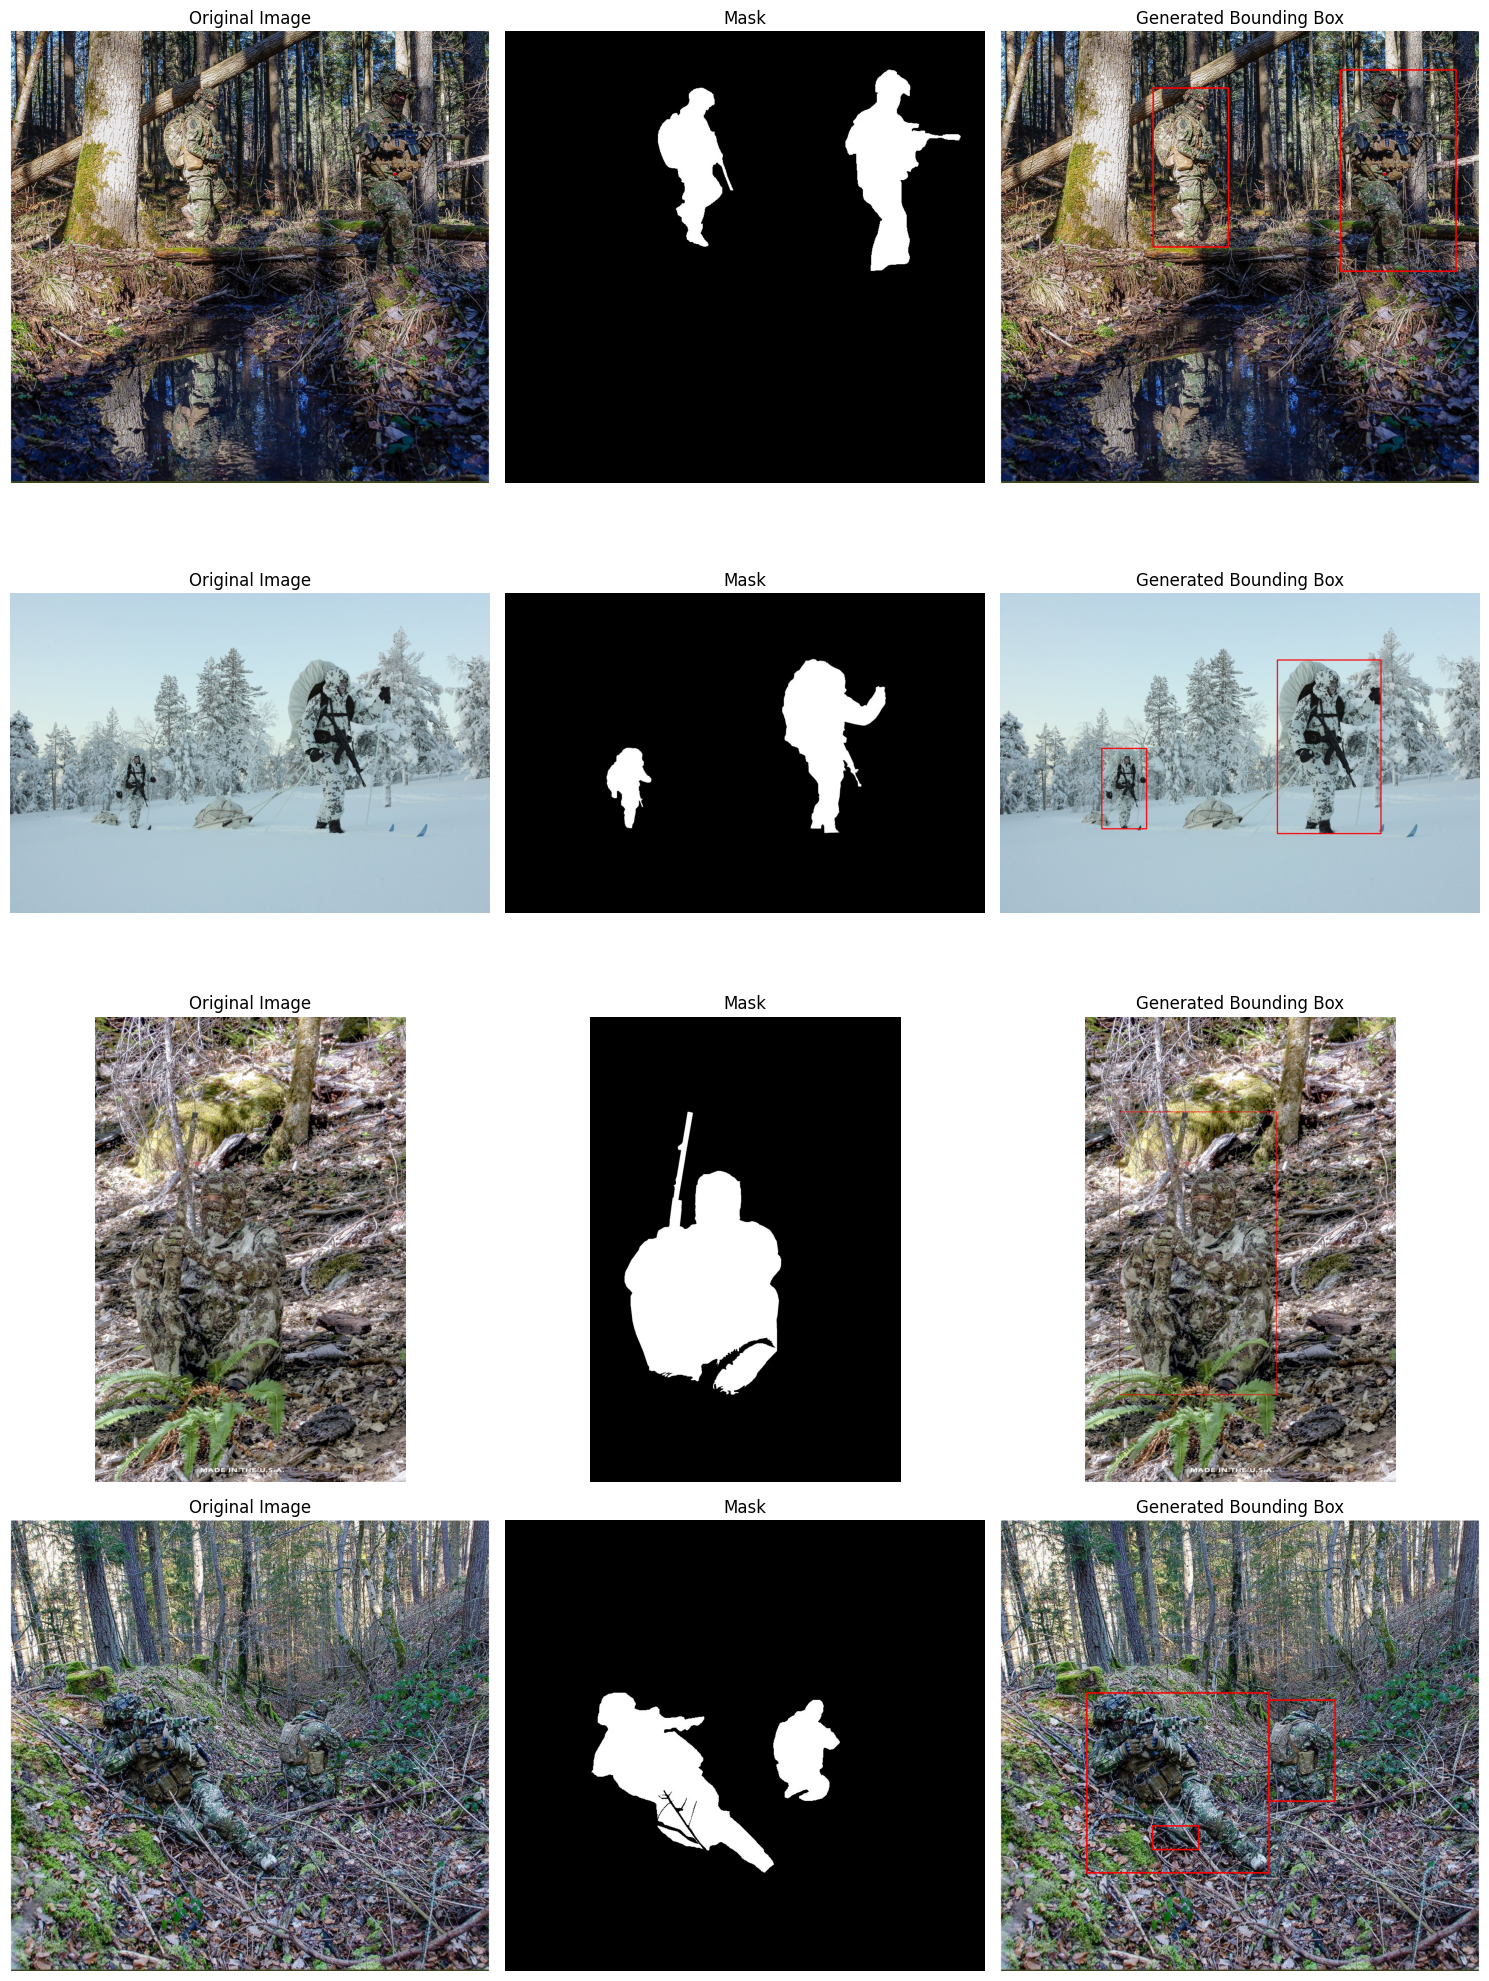

In [129]:
sample_files = random.sample(
    os.listdir(Train_Img_Path),
    4
)

fig, axes = plt.subplots(
    4,
    3,
    figsize=(15,20)
)

for i, file in enumerate(sample_files):

    img_path = os.path.join(
        Train_Img_Path,
        file
    )

    mask_path = os.path.join(
        Train_Mask_Path,
        Path(file).stem + ".jpg"
    )

    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    mask = cv2.imread(
        mask_path,
        cv2.IMREAD_GRAYSCALE
    )

    _, binary = cv2.threshold(
        mask,
        127,
        255,
        cv2.THRESH_BINARY
    )

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary)

    boxed = img_rgb.copy()

    for j in range(1, num_labels):

        x, y, w, h, area = stats[j]

        if area < 500:
            continue

        cv2.rectangle(
            boxed,
            (x,y),
            (x+w,y+h),
            (255,0,0),
            2
        )

    axes[i,0].imshow(img_rgb)
    axes[i,0].set_title("Original Image")
    axes[i,0].axis("off")

    axes[i,1].imshow(mask, cmap="gray")
    axes[i,1].set_title("Mask")
    axes[i,1].axis("off")

    axes[i,2].imshow(boxed)
    axes[i,2].set_title("Generated Bounding Box")
    axes[i,2].axis("off")

plt.tight_layout()
plt.show()